In [2]:

#langgraph provide MemorySaver class to store state in RAM 
#thread denote one interaction with the chatbot
#config file

# add_messages is a function that takes in a list of messages and returns a list of messages. It is used to add messages to the chat state.

# BaseMessage is a class that represents a message in the chat. It has two attributes: content and role. content is the text of the message and role is the role of the message (system, human, or assistant).

import os  # <--- Add this line
from langgraph.graph import StateGraph ,START, END
from typing import TypedDict ,Literal,Annotated
from langchain_ollama import ChatOllama
from dotenv import load_dotenv
from pydantic import BaseModel 
from langchain_core.messages import BaseMessage,SystemMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver

In [3]:
load_dotenv()

ollama_url = os.getenv("OLLAMA_BASE_URL")

model = ChatOllama(
    model="llama3.2:latest", 
    base_url=ollama_url, 
    temperature=0
)

In [4]:

from langgraph.graph.message import add_messages

class chatState(TypedDict):

    messages:Annotated[ list[BaseMessage] , add_messages]


In [5]:
def chat_node(state:chatState):

    #take user query froom state
    meassages = state['messages']

    #send to llm 
    response=model.invoke(meassages)

    #response store state
    return {'messages':[response]}

In [6]:
checkpointer = MemorySaver()
graph = StateGraph(chatState)

graph.add_node('chat_node' , chat_node )

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)    

chatbot = graph.compile(checkpointer=checkpointer)

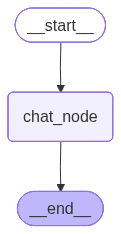

In [7]:
chatbot

In [ ]:
# return humanMesaage content : our one
# AIMessage : what llm return to us
message={'messages':[HumanMessage(content="hello")]}
chatbot.invoke(message)


In [18]:
message={'messages':[HumanMessage(content="my name is anjali. what is my name?")]}
chatbot.invoke(message)['messages'][-1].content


"Your name is Anjali! I'm happy to meet you, Anjali! Is there something I can help you with or would you like to chat?"

In [ ]:
message={'messages':[HumanMessage(content="whats my name")]}
chatbot.invoke(message)


In [10]:
#loop that will take and store input from user till it say exit ,etc
#PROBLEM :this loop invoke model thus lost state
while True:

    #take input from user
    user_message = input('Type here:')
    print('User : ' ,user_message)

    if user_message.strip().lower() in ['exit' , 'quit' , 'bye']:
        break
    response = chatbot.invoke( {'messages': [ HumanMessage(content=user_message) ]} )

    print( 'AI :' , response['messages'][-1].content)

User :  my name is anjali


ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [11]:
#maintaing memory using memorysaver , thread ,config
thread_id='1'

while True:

    #take input from user
    user_message = input('Type here:')
    print('User : ' ,user_message)

    if user_message.strip().lower() in ['exit' , 'quit' , 'bye']:
        break

    config ={'configurable' :{'thread_id':thread_id}}

    response = chatbot.invoke( {'messages': [ HumanMessage(content=user_message) ]} , config = config )

    print( 'AI :' , response['messages'][-1].content)

User :  my name is anjali
AI : Namaste Anjali! It's lovely to meet you. Is there something I can help you with or would you like to chat?
User :  tell me soomething about your model details
AI : Anjali, I'm happy to share some information about my model.

I'm a large language model, which means I was trained on a massive dataset of text from various sources, including books, articles, and online conversations. This training allows me to understand and generate human-like language.

Here are some key details about my model:

1. **Training data**: My training data consists of over 1.5 terabytes of text, which is equivalent to the contents of around 20 million books.
2. **Model architecture**: I'm based on a transformer architecture, which is a type of neural network designed specifically for natural language processing tasks.
3. **Language understanding**: I can understand and process human language in multiple languages, including English, Spanish, French, German, Italian, Portuguese, D

In [ ]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi my name is anjali', additional_kwargs={}, response_metadata={}, id='3f710bad-3786-4208-9991-e2e431705942'), AIMessage(content="Namaste Anjali! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-02-12T11:03:34.274316166Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1335068074, 'load_duration': 1217213308, 'prompt_eval_count': 32, 'prompt_eval_duration': 16738077, 'eval_count': 29, 'eval_duration': 84797889, 'logprobs': None, 'model_name': 'llama3.2:latest', 'model_provider': 'ollama'}, id='lc_run--019c5185-3f4d-7361-9f9a-01f3a8e4baa7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 32, 'output_tokens': 29, 'total_tokens': 61}), HumanMessage(content='whats my name', additional_kwargs={}, response_metadata={}, id='94fb98d2-721b-4748-b18e-a101015a6d1f'), AIMessage(con